<a href="https://colab.research.google.com/github/LielUziahu/Stylophora-pistillata-FPs/blob/main/Spat_size_by_morph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Spat size by morph in ambient conditions


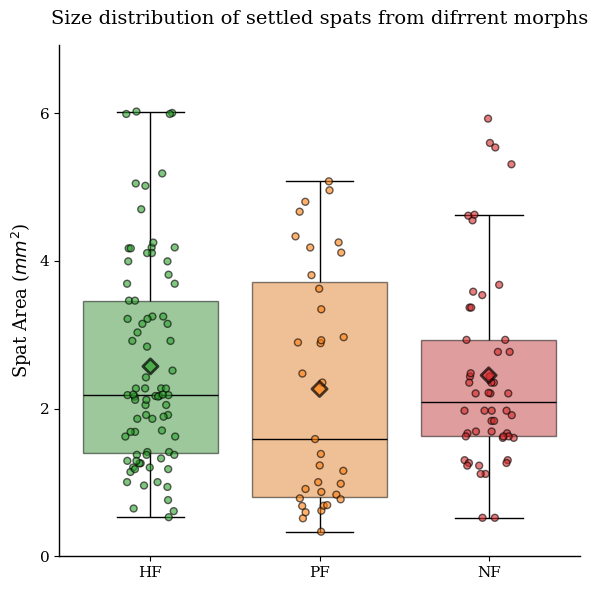

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
filename = 'Ambient_size.csv'
# Using read_csv since the provided file is a CSV
df = pd.read_csv(filename)

# 2. FILTERING
# (Optional) List samples to exclude if necessary, currently commented out
# samples_to_exclude = ['sample_id_1', 'sample_id_2']
# df = df[~df['SampleCode'].isin(samples_to_exclude)].copy()

# 3. CLEANING
# Clean whitespace from string columns
df['morph'] = df['morph'].str.strip()
df['SampleCode'] = df['SampleCode'].str.strip()

# Drop rows where Area or Morph is missing
df = df.dropna(subset=['area mm^2', 'morph'])

# ==========================================
# 4. STATISTICS
# ==========================================
# Extract groups
hf_area = df[df['morph'] == 'HF']['area mm^2']
nf_area = df[df['morph'] == 'NF']['area mm^2']
pf_area = df[df['morph'] == 'PF']['area mm^2']

# Calculate P-value (comparing HF vs NF to match previous guideline logic)
# If you want an ANOVA across all 3, use: stats.f_oneway(hf_area, nf_area, pf_area)
t_stat, p_val = stats.ttest_ind(hf_area, nf_area)

# 5. STYLING
plt.rcParams.update(
    {
        'font.family': 'serif',
        'axes.edgecolor': 'black',
        'axes.linewidth': 1,
        'xtick.color': 'black',
        'ytick.color': 'black',
        'text.color': 'black',
        'axes.labelcolor': 'black',
        'legend.frameon': False,
        'ytick.labelsize': 11,
        'xtick.labelsize': 11,
    }
)

# Define colors (Added specific color for PF)
# HF=Green, NF=Red, PF=Blue/Orange (using Orange for contrast)
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728', 'PF': '#ff7f0e'}
morph_order = ['HF', 'PF', 'NF'] # Logical order: High, Partial, None

plt.figure(figsize=(6, 6))

# Box Plot
ax = sns.boxplot(
    data=df,
    x='morph',
    y='area mm^2',
    order=morph_order,
    hue='morph',
    palette=variant_colors,
    width=0.8,
    showfliers=False,
    linewidth=1,
    legend=False,
    boxprops=dict(edgecolor='black', alpha=0.5),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black'),
)

# Jitter Points
sns.stripplot(
    data=df,
    x='morph',
    y='area mm^2',
    order=morph_order,
    hue='morph',
    palette=variant_colors,
    jitter=0.15,
    size=5,
    linewidth=1,
    edgecolor='black',
    alpha=0.6,
    legend=False,
    zorder=3,
)

# Mean Diamond
means = df.groupby('morph')['area mm^2'].mean().reindex(morph_order)
mean_colors = [variant_colors[m] for m in morph_order]
# scatter x-range must match the number of morphs (0, 1, 2)
plt.scatter(
    range(len(morph_order)),
    means,
    c=mean_colors,
    marker='D',
    s=60,
    edgecolors='black',
    linewidths=2,
    alpha=0.7,
    zorder=4,
)

# 6. ANNOTATIONS (P-value only)
# UPDATE THESE manually based on your actual post-hoc stats results
# letters_map = {'HF': 'a', 'PF': 'ab', 'NF': 'b'}
# y_offset_percent = 0.05

max_val_global = df['area mm^2'].max()

# for i, m in enumerate(morph_order):
#     if m in df['morph'].unique(): # Only plot if morph exists in data
#         subset = df[df['morph'] == m]['area mm^2']
#         highest_point = subset.max()

#         # Add offset
#         pos_y = highest_point + (max_val_global * y_offset_percent)

#         letter = letters_map.get(m, "")
#         plt.text(x=i, y=pos_y, s=letter, ha='center', va='bottom', size=12, weight='bold')

# P-value (Bottom Right)
# Note: This P-value reflects the HF vs NF comparison calculated above
# p_text = f"p(HF vs NF) = {p_val:.4f}" if p_val >= 0.0001 else "p(HF vs NF) < 0.0001"
# plt.text(
#     0.95,
#     0.02,
#     s=p_text,
#     transform=ax.transAxes,
#     ha='right',
#     va='bottom',
#     size=10,
#     style='italic',
#     color='black',
# )

# 7. LABELS & TITLE
plt.ylabel("Spat Area ($mm^2$)", size=13)
plt.xlabel("") # Hide X label as categories are self-explanatory
plt.title("Size distribution of settled spats from difrrent morphs", size=14, pad=15)

# Adjust Y limit to fit annotations
plt.ylim(0, max_val_global * 1.15)
# Optional: Set specific ticks if needed
plt.yticks(np.arange(0, max_val_global, 2))

sns.despine()
plt.tight_layout()

# 8. SAVING
plt.savefig("Spat_Size_by_morph.pdf", dpi=600)
plt.savefig("Spat_Size_by_morph.tiff", dpi=600)
plt.savefig("Spat_Size_by_morph_transparent.svg", transparent=True)
plt.savefig("Spat_Size_by_morph_white_bg.svg", facecolor='white')
plt.savefig("Spat_Size_by_morph.png", dpi=600)

plt.show()

Spat size by morph in light

=== Two-Way ANOVA Results (Size) ===
                            sum_sq     df         F    PR(>F)
C(morph)                  0.016480    1.0  0.007680  0.930286
C(LightDepth)            16.514207    2.0  3.847754  0.023478
C(morph):C(LightDepth)    6.027902    2.0  1.404481  0.248725
Residual                319.747129  149.0       NaN       NaN

=== Tukey's HSD Post-hoc Test Results ===
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
 HF_10m  HF_50m   0.6884 0.5124 -0.4585 1.8352  False
 HF_10m HF_Dark   1.3024 0.0976   -0.13 2.7348  False
 HF_10m  NF_10m   0.1274 0.9978 -0.7026 0.9575  False
 HF_10m  NF_50m   0.8579 0.5663 -0.6423 2.3581  False
 HF_10m NF_Dark   0.2294 0.9978 -1.2708 1.7296  False
 HF_50m HF_Dark   0.6141 0.8993 -1.0715 2.2996  False
 HF_50m  NF_10m  -0.5609 0.7668 -1.7767 0.6549  False
 HF_50m  NF_50m   0.1695 0.9998  -1.574  1.913  False
 HF_50m NF_Dark 

/tmp/ipython-input-1234788936.py:132: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = sub.groupby(x_col)["Size"].mean().reindex(x_order)
/tmp/ipython-input-1234788936.py:132: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = sub.groupby(x_col)["Size"].mean().reindex(x_order)
/tmp/ipython-input-1234788936.py:160: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch = mpatches.Patch(color=variant_colors[morph], label=morph, edgecolor='black', linewidth=1, alpha=0.6)


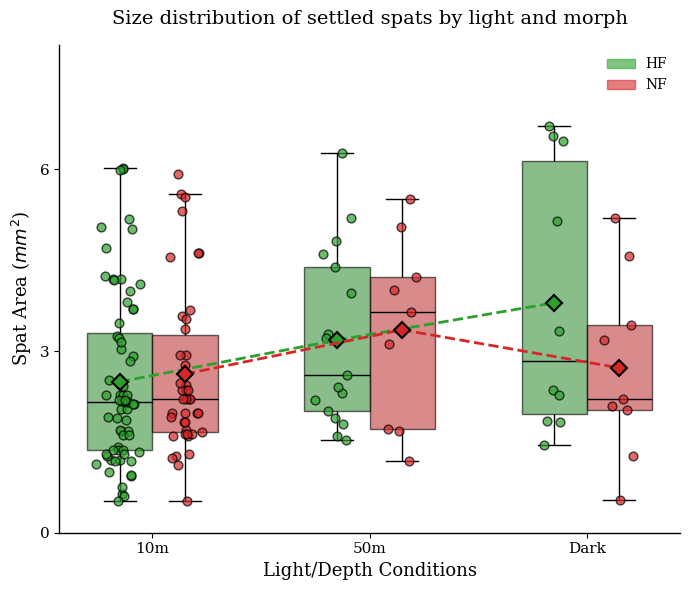

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
filename = "Light_size.csv"
df = pd.read_csv(filename)

# --- Handle 'morph' and 'color' columns consistently ---
# The file has 'color' column for morphs (HF/NF/PF)
if 'color' in df.columns:
    # Rename 'color' to 'morph'
    df = df.rename(columns={'color': 'morph'})

# Drop rows with missing values in critical columns
df = df.dropna(subset=['area mm^2', 'morph', 'LightDepth'])

# --- FILTERING ---
# 1. Remove PF (Partial Fluorescence)
df = df[df['morph'] != 'PF'].copy()

# 2. Rename Target Variable
# Rename 'area mm^2' to 'Size' to match the script logic
df = df.rename(columns={"area mm^2": "Size"})

# Clean 'morph' strings
df['morph'] = df['morph'].str.strip()

# Clean and Order the LightDepth column
# Logic: High Light (10m) -> Low Light (50m) -> No Light (Dark)
df["LightDepth"] = df["LightDepth"].astype(str).str.strip()
light_order = ["10m", "50m", "Dark"]
df["LightDepth"] = pd.Categorical(df["LightDepth"], categories=light_order, ordered=True)

# Drop rows with unexpected LightDepth values
df = df[df["LightDepth"].isin(light_order)].copy()
df = df.reset_index(drop=True)

# ==========================================
# 2. STATISTICS (Two-Way ANOVA & Tukey's HSD)
# ==========================================
print("=== Two-Way ANOVA Results (Size) ===")
# Model: Size depends on morph and LightDepth
model = ols("Size ~ C(morph) + C(LightDepth) + C(morph):C(LightDepth)", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# 2.1 Tukey's HSD Post-hoc Test
df['group'] = df['morph'].astype(str) + "_" + df['LightDepth'].astype(str)
tukey_result = pairwise_tukeyhsd(endog=df['Size'], groups=df['group'], alpha=0.05)

print("\n=== Tukey's HSD Post-hoc Test Results ===")
print(tukey_result)

# ==========================================
# 3. STYLING SETUP
# ==========================================
plt.rcParams.update({
    "font.family": "serif",
    "axes.edgecolor": "black", "axes.linewidth": 1,
    "xtick.color": "black", "ytick.color": "black",
    "text.color": "black", "axes.labelcolor": "black",
    "legend.frameon": False,
    "ytick.labelsize": 11,
    "xtick.labelsize": 11
})

# Colors matching the previous file
variant_colors = {"HF": "#2ca02c", "NF": "#d62728"}
morph_order = ["HF", "NF"]

fig, ax = plt.subplots(figsize=(7, 6))

# ==========================================
# 4. PLOT CONSTRUCTION
# ==========================================
box_width = 0.6
offset = box_width / 4

x_positions = {
    "HF": -offset,
    "NF": +offset
}

# Variable to plot on X-axis
x_col = "LightDepth"
x_order = light_order

for morph in morph_order:
    sub = df[df["morph"] == morph]
    if sub.empty: continue

    # A. Boxplots
    sns.boxplot(
        data=sub, x=x_col, y="Size",
        order=x_order,
        width=box_width / 2,
        color=variant_colors[morph],
        showfliers=False, linewidth=1,
        boxprops=dict(edgecolor="black", alpha=0.6),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="black"),
        ax=ax,
        positions=np.arange(len(x_order)) + x_positions[morph]
    )

    # B. Jittered points
    for i, level in enumerate(x_order):
        y = sub[sub[x_col] == level]["Size"]
        if len(y) > 0:
            # Add random jitter to x
            x_vals = np.random.normal(i + x_positions[morph], 0.04, size=len(y))

            ax.scatter(
                x_vals, y,
                s=40, c=variant_colors[morph],
                edgecolors="black", linewidths=1,
                alpha=0.7, zorder=3
            )

    # C. Mean Diamonds
    means = sub.groupby(x_col)["Size"].mean().reindex(x_order)

    # Handle potential missing data for lines
    valid_indices = ~means.isna()
    if valid_indices.any():
        ax.plot(
            np.arange(len(x_order))[valid_indices] + x_positions[morph],
            means[valid_indices],
            marker="D", linestyle="--",
            markersize=8,
            markerfacecolor=variant_colors[morph],
            markeredgecolor="black",
            markeredgewidth=1.5,
            linewidth=2,
            color=variant_colors[morph],
            zorder=4
        )

# ==========================================
# 5. LABELS, LEGEND & ANNOTATION
# ==========================================
ax.set_ylabel("Spat Area ($mm^2$)", fontsize=13)
ax.set_xlabel("Light/Depth Conditions", fontsize=13)
ax.set_title("Size distribution of settled spats by light and morph", fontsize=14, pad=15)

# Custom Legend
legend_handles = []
for morph in morph_order:
    patch = mpatches.Patch(color=variant_colors[morph], label=morph, edgecolor='black', linewidth=1, alpha=0.6)
    legend_handles.append(patch)
ax.legend(handles=legend_handles, labels=morph_order, title=None, frameon=False, loc="upper right")

# Fix X-axis ticks
ax.set_xticks(np.arange(len(x_order)))
ax.set_xticklabels(x_order)

# Y-axis formatting
max_val = df["Size"].max()
ax.set_ylim(0, max_val * 1.2)
# Adjusted tick frequency to 0.5 for size data (since values are smaller than respiration)
ax.yaxis.set_major_locator(ticker.MultipleLocator(3)) # Changed from 0.5 to 3

sns.despine(ax=ax)
fig.tight_layout()

# Save options
plt.savefig("Size_by_Light_Morph_Style.png", dpi=600)
plt.savefig("Size_by_Light_Morph_Style.pdf", dpi=600)
plt.savefig("Size_by_Light_Morph_Style.tiff", dpi=600) # Added TIFF save option
plt.savefig("Size_by_Light_Morph_Style_transparent.svg", transparent=True) # Added SVG transparent save option
plt.savefig("Size_by_Light_Morph_Style_white_bg.svg", facecolor='white') # Added SVG white background save option
plt.show()

spat size bu morph and pH

=== Two-Way ANOVA Results (Size) ===


,sum_sq,df,F,PR(>F)
C(morph),0.178519,1.0,0.125906,0.723060
C(pH),4.237011,2.0,1.494142,0.226741
C(morph):C(pH),2.734192,2.0,0.964187,0.382920
Residual,307.678722,217.0,NaN,NaN



=== Tukey's HSD Post-hoc Test Results ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
HF_7.6 HF_7.8  -0.3519 0.8787 -1.2669 0.5632  False
HF_7.6 HF_8.2   0.1239 0.9969 -0.6244 0.8721  False
HF_7.6 NF_7.6   0.4134 0.8964 -0.7074 1.5341  False
HF_7.6 NF_7.8   -0.073    1.0 -1.1073 0.9614  False
HF_7.6 NF_8.2   0.0032    1.0 -0.7994 0.8057  False
HF_7.8 HF_8.2   0.4757 0.4499 -0.2725  1.224  False
HF_7.8 NF_7.6   0.7652 0.3669 -0.3555 1.8859  False
HF_7.8 NF_7.8   0.2789 0.9714 -0.7555 1.3132  False
HF_7.8 NF_8.2    0.355    0.8 -0.4475 1.1576  False
HF_8.2 NF_7.6   0.2895 0.9594 -0.6997 1.2787  False
HF_8.2 NF_7.8  -0.1969 0.9882 -1.0871 0.6934  False
HF_8.2 NF_8.2  -0.1207 0.9927 -0.7262 0.4848  False
NF_7.6 NF_7.8  -0.4863 0.8614 -1.7064 0.7337  False
NF_7.6 NF_8.2  -0.4102 0.8623 -1.4411 0.6207  False
NF_7.8 NF_8.2   0.0761 0.9999 -0.8602 1.0125  False
---------------------

/tmp/ipython-input-1958206348.py:124: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = sub.groupby("pH")["Size"].mean().reindex(ph_order) # Changed to mean()
/tmp/ipython-input-1958206348.py:124: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = sub.groupby("pH")["Size"].mean().reindex(ph_order) # Changed to mean()


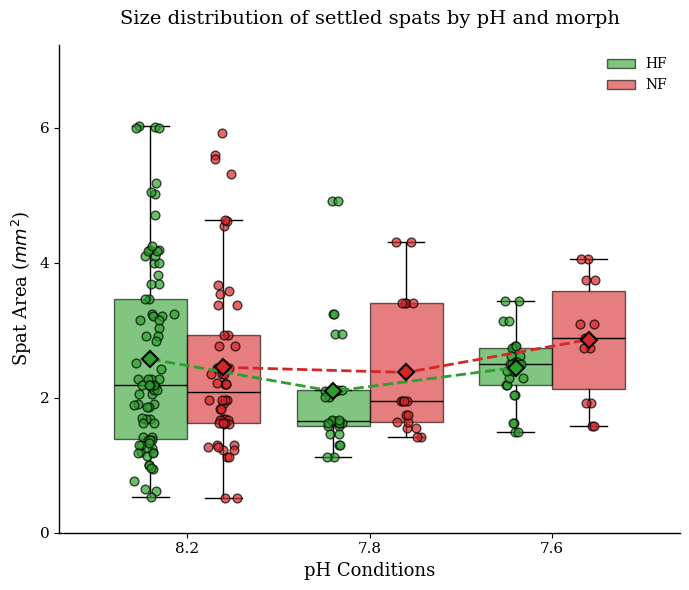

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
filename = "pH_size.csv"
df = pd.read_csv(filename)

# Standardize columns
df.columns = df.columns.str.strip()
if 'color' in df.columns: df = df.rename(columns={'color': 'morph'})
if 'area mm^2' in df.columns: df = df.rename(columns={'area mm^2': 'Size'})
else:
    cols = [c for c in df.columns if 'area' in c.lower()]
    if cols: df = df.rename(columns={cols[0]: 'Size'})

df['morph'] = df['morph'].str.strip()
df['pH'] = df['pH'].astype(str).str.strip()

# Drop NaNs
df = df.dropna(subset=['Size', 'morph', 'pH'])

# ==========================================
# 2. FILTER & PREP FOR PLOT
# ==========================================
# Remove PF
df_plot = df[df['morph'] != 'PF'].copy()

# Order pH: 8.2 (Control) -> 7.8 -> 7.6 (Stress)
ph_order = ["8.2", "7.8", "7.6"]
# Filter to keep only these levels if they exist
df_plot = df_plot[df_plot["pH"].isin(ph_order)].copy()
df_plot["pH"] = pd.Categorical(df_plot["pH"], categories=ph_order, ordered=True)

# ==========================================
# 2.1 STATISTICS (Two-Way ANOVA & Tukey's HSD) - ADDED HERE
# ==========================================
print("=== Two-Way ANOVA Results (Size) ===")
# Model: Size depends on morph and pH
model = ols("Size ~ C(morph) + C(pH) + C(morph):C(pH)", data=df_plot).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
display(anova_table) # Use display for DataFrame

# Tukey's HSD Post-hoc Test
df_plot['group'] = df_plot['morph'].astype(str) + "_" + df_plot['pH'].astype(str)
tukey_result = pairwise_tukeyhsd(endog=df_plot['Size'], groups=df_plot['group'], alpha=0.05)

print("\n=== Tukey's HSD Post-hoc Test Results ===")
print(tukey_result) # print for summary table

# ==========================================
# 3. PLOTTING
# ==========================================
plt.rcParams.update({
    "font.family": "serif",
    "axes.edgecolor": "black", "axes.linewidth": 1,
    "xtick.color": "black", "ytick.color": "black",
    "text.color": "black", "axes.labelcolor": "black",
    "legend.frameon": False,
    "ytick.labelsize": 11,
    "xtick.labelsize": 11
})

# COLORS FROM Light_size.py
variant_colors = {"HF": "#2ca02c", "NF": "#d62728"}
morph_order = ["HF", "NF"]

fig, ax = plt.subplots(figsize=(7, 6))

box_width = 0.8 # Changed to make boxes wider
offset = box_width / 4
x_positions = {"HF": -offset, "NF": +offset}

for morph in morph_order:
    sub = df_plot[df_plot["morph"] == morph]
    if sub.empty: continue

    positions = np.arange(len(ph_order)) + x_positions[morph]

    # A. Boxplots
    # Using ax.boxplot to mimic sns.boxplot style from Light_size.py
    data_to_plot = [sub[sub["pH"] == level]["Size"].values for level in ph_order]

    # Handle empty data arrays to avoid errors
    data_to_plot = [d if len(d) > 0 else np.array([]) for d in data_to_plot]

    bp = ax.boxplot(data_to_plot, positions=positions, widths=box_width/2,
                    patch_artist=True, showfliers=False)

    # Style match: alpha=0.6, black edges
    for patch in bp['boxes']:
        patch.set_facecolor(variant_colors[morph])
        patch.set_alpha(0.6) # Matched to Light_size.py alpha
        patch.set_edgecolor('black')
        patch.set_linewidth(1)

    for element in ['whiskers', 'caps', 'medians']:
        plt.setp(bp[element], color='black', linewidth=1)

    # B. Jittered Points
    for i, level in enumerate(ph_order):
        y = sub[sub["pH"] == level]["Size"]
        if len(y) > 0:
            # Jitter
            x_vals = np.random.normal(i + x_positions[morph], 0.04, size=len(y))

            ax.scatter(
                x_vals, y,
                s=40, c=variant_colors[morph],
                edgecolors="black", linewidths=1,
                alpha=0.7, zorder=3
            )

    # C. Mean Diamonds (Changed from Median Diamonds)
    means = sub.groupby("pH")["Size"].mean().reindex(ph_order) # Changed to mean()
    valid = ~means.isna()
    if valid.any():
        ax.plot(
            np.arange(len(ph_order))[valid] + x_positions[morph],
            means[valid], # Changed to means
            marker="D", linestyle="--",
            markersize=8,
            markerfacecolor=variant_colors[morph],
            markeredgecolor="black",
            markeredgewidth=1.5,
            linewidth=2,
            color=variant_colors[morph],
            zorder=4
        )

# Labels & Legend
ax.set_ylabel("Spat Area ($mm^2$)", fontsize=13)
ax.set_xlabel("pH Conditions", fontsize=13)
ax.set_title("Size distribution of settled spats by pH and morph", fontsize=14, pad=15)

# Legend
handles = [mpatches.Patch(color=variant_colors[m], label=m, alpha=0.6, ec='black') for m in morph_order]
ax.legend(handles=handles, title=None, frameon=False, loc="upper right")

# Ticks
ax.set_xticks(np.arange(len(ph_order)))
ax.set_xticklabels(ph_order)

# Y-axis formatting
max_val = df_plot["Size"].max()
ax.set_ylim(0, max_val * 1.2)
ax.yaxis.set_major_locator(ticker.MultipleLocator(2.0)) # Changed to tick every 2 units

sns.despine(ax=ax)
fig.tight_layout()

plt.savefig("Size_by_pH_Morph_Style.png", dpi=600)
plt.savefig("Size_by_pH_Morph_Style.pdf", dpi=600)
plt.savefig("Size_by_pH_Morph_Style.tiff", dpi=600) # Added TIFF save option
plt.savefig("Size_by_pH_Morph_Style_transparent.svg", transparent=True) # Added SVG transparent save option
plt.savefig("Size_by_pH_Morph_Style_white_bg.svg", facecolor='white') # Added SVG white background save option
plt.show()

=== Two-Way ANOVA Results (Size) ===


,sum_sq,df,F,PR(>F)
C(morph),0.080984,1.0,0.042010,0.837810
C(Temp),8.031870,2.0,2.083243,0.127233
C(morph):C(Temp),1.643489,2.0,0.426275,0.653531
Residual,383.618782,199.0,NaN,NaN



=== Tukey's HSD Post-hoc Test Results ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
 HF_23  HF_27   0.3724 0.8563 -0.5536 1.2984  False
 HF_23  HF_32   0.1742  0.999 -1.1632 1.5116  False
 HF_23  NF_23  -0.1207 0.9964 -0.8273 0.5859  False
 HF_23  NF_27   0.3284 0.8936 -0.5568 1.2136  False
 HF_23  NF_32   0.6846  0.724 -0.7176 2.0868  False
 HF_27  HF_32  -0.1983  0.999 -1.7021 1.3056  False
 HF_27  NF_23  -0.4932  0.703 -1.4791 0.4928  False
 HF_27  NF_27   -0.044    1.0 -1.1649 1.0769  False
 HF_27  NF_32   0.3122 0.9925 -1.2495 1.8739  False
 HF_32  NF_23  -0.2949 0.9898 -1.6745 1.0847  False
 HF_32  NF_27   0.1543 0.9997 -1.3248 1.6333  False
 HF_32  NF_32   0.5104 0.9672 -1.3254 2.3462  False
 NF_23  NF_27   0.4492 0.7486 -0.4986 1.3969  False
 NF_23  NF_32   0.8053 0.5952 -0.6372 2.2478  False
 NF_27  NF_32   0.3561 0.9854 -1.1817  1.894  False
---------------------

/tmp/ipython-input-1768960600.py:124: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = sub.groupby("Temp")["Size"].mean().reindex(Temp_order) # Changed to mean()
/tmp/ipython-input-1768960600.py:124: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = sub.groupby("Temp")["Size"].mean().reindex(Temp_order) # Changed to mean()


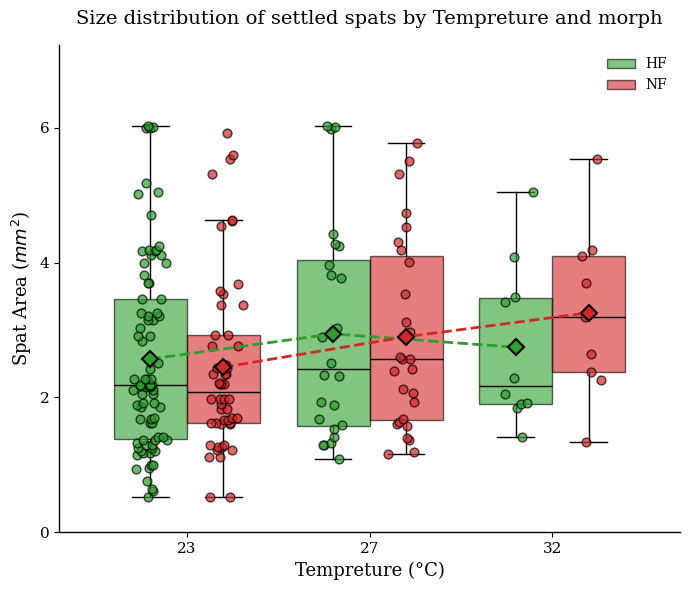

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
filename = "Temp_size.csv"
df = pd.read_csv(filename)

# Standardize columns
df.columns = df.columns.str.strip()
if 'color' in df.columns: df = df.rename(columns={'color': 'morph'})
if 'area mm^2' in df.columns: df = df.rename(columns={'area mm^2': 'Size'})
else:
    cols = [c for c in df.columns if 'area' in c.lower()]
    if cols: df = df.rename(columns={cols[0]: 'Size'})

df['morph'] = df['morph'].str.strip()
df['Temp'] = df['temp'].astype(str).str.strip() # Fixed 'Temp' to 'temp'

# Drop NaNs
df = df.dropna(subset=['Size', 'morph', 'Temp'])

# ==========================================
# 2. FILTER & PREP FOR PLOT
# ==========================================
# Remove PF
df_plot = df[df['morph'] != 'PF'].copy()

# Order pH: 23 (Control) -> 27 -> 32 (Stress)
Temp_order = ["23", "27", "32"]
# Filter to keep only these levels if they exist
df_plot = df_plot[df_plot["Temp"].isin(Temp_order)].copy() # Fixed 'ph_order' to 'Temp_order'
df_plot["Temp"] = pd.Categorical(df_plot["Temp"], categories=Temp_order, ordered=True)

# ==========================================
# 2.1 STATISTICS (Two-Way ANOVA & Tukey's HSD) - ADDED HERE
# ==========================================
print("=== Two-Way ANOVA Results (Size) ===")
# Model: Size depends on morph and Temp
model = ols("Size ~ C(morph) + C(Temp) + C(morph):C(Temp)", data=df_plot).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
display(anova_table) # Use display for DataFrame

# Tukey's HSD Post-hoc Test
df_plot['group'] = df_plot['morph'].astype(str) + "_" + df_plot['Temp'].astype(str)
tukey_result = pairwise_tukeyhsd(endog=df_plot['Size'], groups=df_plot['group'], alpha=0.05)

print("\n=== Tukey's HSD Post-hoc Test Results ===")
print(tukey_result) # print for summary table

# ==========================================
# 3. PLOTTING
# ==========================================
plt.rcParams.update({
    "font.family": "serif",
    "axes.edgecolor": "black", "axes.linewidth": 1,
    "xtick.color": "black", "ytick.color": "black",
    "text.color": "black", "axes.labelcolor": "black",
    "legend.frameon": False,
    "ytick.labelsize": 11,
    "xtick.labelsize": 11
})

# COLORS FROM Light_size.py
variant_colors = {"HF": "#2ca02c", "NF": "#d62728"}
morph_order = ["HF", "NF"]

fig, ax = plt.subplots(figsize=(7, 6))

box_width = 0.8 # Changed to make boxes wider
offset = box_width / 4
x_positions = {"HF": -offset, "NF": +offset}

for morph in morph_order:
    sub = df_plot[df_plot["morph"] == morph]
    if sub.empty: continue

    positions = np.arange(len(Temp_order)) + x_positions[morph] # Fixed 'ph_order' to 'Temp_order'

    # A. Boxplots
    # Using ax.boxplot to mimic sns.boxplot style from Light_size.py
    data_to_plot = [sub[sub["Temp"] == level]["Size"].values for level in Temp_order]

    # Handle empty data arrays to avoid errors
    data_to_plot = [d if len(d) > 0 else np.array([]) for d in data_to_plot]

    bp = ax.boxplot(data_to_plot, positions=positions, widths=box_width/2,
                    patch_artist=True, showfliers=False)

    # Style match: alpha=0.6, black edges
    for patch in bp['boxes']:
        patch.set_facecolor(variant_colors[morph])
        patch.set_alpha(0.6) # Matched to Light_size.py alpha
        patch.set_edgecolor('black')
        patch.set_linewidth(1)

    for element in ['whiskers', 'caps', 'medians']:
        plt.setp(bp[element], color='black', linewidth=1)

    # B. Jittered Points
    for i, level in enumerate(Temp_order): # Fixed 'ph_order' to 'Temp_order'
        y = sub[sub["Temp"] == level]["Size"]
        if len(y) > 0:
            # Jitter
            x_vals = np.random.normal(i + x_positions[morph], 0.04, size=len(y))

            ax.scatter(
                x_vals, y,
                s=40, c=variant_colors[morph],
                edgecolors="black", linewidths=1,
                alpha=0.7, zorder=3
            )

    # C. Mean Diamonds (Changed from Median Diamonds)
    means = sub.groupby("Temp")["Size"].mean().reindex(Temp_order) # Changed to mean()
    valid = ~means.isna()
    if valid.any():
        ax.plot(
            np.arange(len(Temp_order))[valid] + x_positions[morph], # Fixed 'ph_order' to 'Temp_order'
            means[valid], # Changed to means
            marker="D", linestyle="--",
            markersize=8,
            markerfacecolor=variant_colors[morph],
            markeredgecolor="black",
            markeredgewidth=1.5,
            linewidth=2,
            color=variant_colors[morph],
            zorder=4
        )

# Labels & Legend
plt.ylabel("Spat Area ($mm^2$)", fontsize=13)
plt.xlabel("Tempreture (°C)", fontsize=13)
plt.title("Size distribution of settled spats by Tempreture and morph", fontsize=14, pad=15)

# Legend
handles = [mpatches.Patch(color=variant_colors[m], label=m, alpha=0.6, ec='black') for m in morph_order]
ax.legend(handles=handles, title=None, frameon=False, loc="upper right")

# Ticks
ax.set_xticks(np.arange(len(Temp_order))) # Fixed 'Temph_order' to 'Temp_order'
ax.set_xticklabels(Temp_order) # Fixed 'Temph_order' to 'Temp_order'

# Y-axis formatting
max_val = df_plot["Size"].max()
ax.set_ylim(0, max_val * 1.2)
ax.yaxis.set_major_locator(ticker.MultipleLocator(2.0)) # Changed to tick every 2 units

sns.despine(ax=ax)
fig.tight_layout()

plt.savefig("Size_by_Temp_Morph_Style.png", dpi=600)
plt.savefig("Size_by_Temp_Morph_Style.pdf", dpi=600)
plt.savefig("Size_by_Temp_Morph_Style.tiff", dpi=600) # Added TIFF save option
plt.savefig("Size_by_Temp_Morph_Style_transparent.svg", transparent=True) # Added SVG transparent save option
plt.savefig("Size_by_Temp_Morph_Style_white_bg.svg", facecolor='white') # Added SVG white background save option
plt.show()